# 11 — Трендовые линии на 1m: вероятность отскока в тренде

Постановка (user): на минутках, КОГДА У НАС ТРЕНД и цена возвращается к линии —
какова вероятность отскока в будущем? Метрика — двухбарьерная: от касания смотрим,
что раньше за NB баров: ход +b в сторону тренда (отскок) или −b (пробой).
`P(bounce)` = доля отскоков. Планка торгуемости при ±b=0.4%, costs 0.15%: **P>~69%**.

Причинно: пивоты с лагом k, луч через две последние; гейт тренда (SMA); контроль —
параллельная линия со случайным сдвигом; train 2024 / test 2025.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
rng = np.random.default_rng(0)
full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::11][:12]
START, END = "2024-01-01", "2025-07-01"
K = 60; TOL = 0.0015; BREAK = 0.003; LIFE = 1440; CD = 30
TREND = 480; B = 0.004; NB = 120; COST = 0.0015
SPLIT = pd.Timestamp("2025-01-01", tz="UTC")
print(len(UNIV), "symbols:", UNIV)

12 symbols: ['API3USDT', 'BATUSDT', 'CELOUSDT', 'CVCUSDT', 'FLOWUSDT', 'HIGHUSDT', 'JSTUSDT', 'MTLUSDT', 'OXTUSDT', 'RPLUSDT', 'SUIUSDT', 'TWTUSDT']


In [2]:
def pivots_vec(df, k=K):
    """Vectorised swing pivots (window +-k). Confirmed only at bar i+k (causal use)."""
    h = df["high"]; l = df["low"]; win = 2*k + 1
    is_hi = (h.values == h.rolling(win, center=True).max().values)
    is_lo = (l.values == l.rolling(win, center=True).min().values)
    return is_hi, is_lo

def build_segs(df, side, k=K, life=LIFE):
    hi, lo = pivots_vec(df, k); n = len(df)
    pr = df["low"].to_numpy() if side == "up" else df["high"].to_numpy()
    idx = np.where(lo if side == "up" else hi)[0]
    idx = idx[(idx >= k) & (idx < n - k)]
    piv = [(int(i), float(pr[i])) for i in idx]
    segs = []
    for j in range(1, len(piv)):
        (i1, p1), (i2, p2) = piv[j-1], piv[j]
        if side == "up" and not (p2 > p1): continue
        if side == "down" and not (p2 < p1): continue
        if i2 == i1: continue
        slope = (p2 - p1) / (i2 - i1)
        start = i2 + k
        nxt = (piv[j+1][0] + k) if j+1 < len(piv) else n
        segs.append((i1, p1, i2, p2, slope, start, min(nxt, start + life, n)))
    return segs

def barrier(c, h, l, t, side, b=B, nb=NB):
    """From entry close c[t], which barrier hits first within nb bars:
    with-trend (+b) = bounce(1), or against (-b) = break(0). None if neither."""
    c0 = c[t]; n = len(c)
    up_lvl = c0 * (1 + b); dn_lvl = c0 * (1 - b)
    for f in range(t+1, min(t+nb+1, n)):
        hit_up = h[f] >= up_lvl; hit_dn = l[f] <= dn_lvl
        if side == "up":   # support -> long -> bounce = up barrier first
            if hit_up and not hit_dn: return 1
            if hit_dn and not hit_up: return 0
            if hit_up and hit_dn: return 0   # both in one bar -> conservative: break
        else:              # resistance -> short -> bounce = down barrier first
            if hit_dn and not hit_up: return 1
            if hit_up and not hit_dn: return 0
            if hit_up and hit_dn: return 0
    return None

def scan(df, segs, side, sma, offset=0.0, tol=TOL, brk=BREAK):
    """Touches in-trend (SMA gate) of the (optionally shifted) line. Returns touch bars t."""
    C = df["close"].to_numpy(); H = df["high"].to_numpy(); L = df["low"].to_numpy()
    ev = []
    for (i1, p1, i2, p2, slope, start, end) in segs:
        for t in range(max(start, 1), end):
            lv = (p2 + slope * (t - i2)) * (1 + offset)
            if lv <= 0 or not np.isfinite(sma[t]): continue
            if side == "up":
                if C[t] < lv * (1 - brk): break
                if C[t] <= sma[t]: continue                    # only in uptrend
                if C[t-1] > lv * (1 + tol) and L[t] <= lv * (1 + tol): ev.append(t)
            else:
                if C[t] > lv * (1 + brk): break
                if C[t] >= sma[t]: continue                    # only in downtrend
                if C[t-1] < lv * (1 - tol) and H[t] >= lv * (1 - tol): ev.append(t)
    out = []; last = -10**9
    for t in sorted(ev):
        if t - last >= CD: out.append(t); last = t
    return out

In [3]:
rows = []
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, "1min")
    if len(df) < 5000: continue
    C = df["close"].to_numpy(); H = df["high"].to_numpy(); L = df["low"].to_numpy()
    n = len(df); ts = df.index
    sma = df["close"].rolling(TREND).mean().to_numpy()
    for side in ("up", "down"):
        segs = build_segs(df, side)
        if not segs: continue
        off = rng.choice([-1, 1]) * rng.uniform(0.01, 0.04)
        for kind, o in [("real", 0.0), ("matched", off)]:
            for t in scan(df, segs, side, sma, offset=o):
                if t + NB >= n: continue
                res = barrier(C, H, L, t, side)
                if res is None: continue
                rows.append(dict(kind=kind, side=side,
                                 period=("train" if ts[t] < SPLIT else "test"), bounce=res))
    print(f"  {si+1}/{len(UNIV)} {sym}")
E = pd.DataFrame(rows)
print("\nresolved touches:")
print(E.groupby(["period", "kind"]).size().unstack().to_string())

  1/12 API3USDT


  2/12 BATUSDT


  3/12 CELOUSDT


  4/12 CVCUSDT


  5/12 FLOWUSDT


...

  8/12 MTLUSDT


  9/12 OXTUSDT


  10/12 RPLUSDT


  11/12 SUIUSDT


  12/12 TWTUSDT

resolved touches:
kind    matched   real
period                
test        971   5740
train      2049  12915


In [4]:
BREAKEVEN = 0.5 + COST / (2 * B)   # P needed to beat cost at +-B barriers
print(f"barrier +-{B*100:.1f}%, cost {COST*100:.2f}% -> breakeven P(bounce) = {BREAKEVEN:.1%}\n")
print("=== P(bounce) by period / kind / side ===")
tab = E.groupby(["period", "kind", "side"]).bounce.agg(["size", "mean"])
tab["mean"] = (tab["mean"] * 100).round(1)
print(tab.rename(columns={"size": "n", "mean": "P_bounce%"}).to_string())
print("\n=== overall P(bounce) real vs matched ===")
ov = E.groupby(["period", "kind"]).bounce.agg(["size", "mean"])
ov["mean"] = (ov["mean"] * 100).round(1)
print(ov.rename(columns={"size": "n", "mean": "P_bounce%"}).to_string())

barrier +-0.4%, cost 0.15% -> breakeven P(bounce) = 68.8%

=== P(bounce) by period / kind / side ===
                        n  P_bounce%
period kind    side                 
test   matched down   583       53.3
               up     388       47.2
       real    down  2959       53.8
               up    2781       51.8
train  matched down  1200       47.5
               up     849       51.5
       real    down  6222       50.1
               up    6693       50.3

=== overall P(bounce) real vs matched ===
                    n  P_bounce%
period kind                     
test   matched    971       50.9
       real      5740       52.8
train  matched   2049       49.1
       real     12915       50.2


[saved] notebooks\levels\_out\11_bounce_prob.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/11_bounce_prob.png')

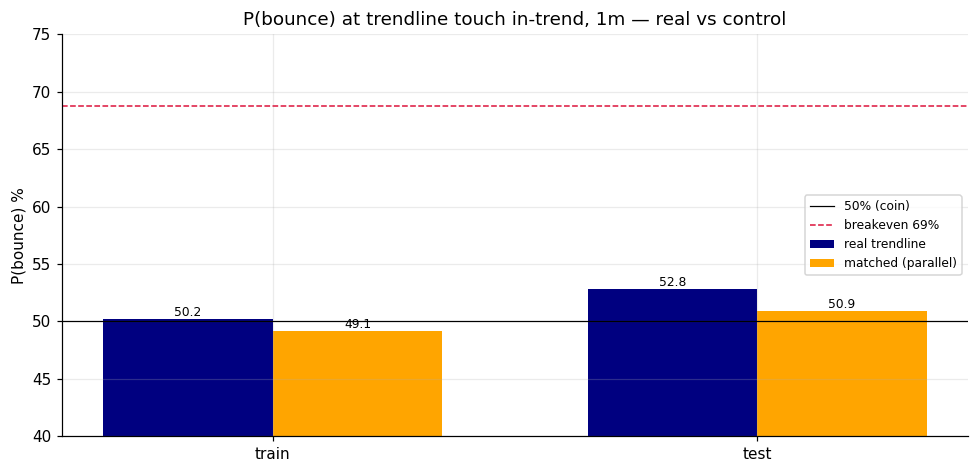

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.4))
piv = E.groupby(["period", "kind"]).bounce.mean().unstack().reindex(["train", "test"]) * 100
x = np.arange(len(piv)); w = 0.35
ax.bar(x - w/2, piv["real"], w, color="navy", label="real trendline")
ax.bar(x + w/2, piv["matched"], w, color="orange", label="matched (parallel)")
ax.axhline(50, color="k", lw=0.8, label="50% (coin)")
ax.axhline(BREAKEVEN*100, color="crimson", ls="--", lw=1.0, label=f"breakeven {BREAKEVEN:.0%}")
ax.set_xticks(x); ax.set_xticklabels(piv.index); ax.set_ylabel("P(bounce) %"); ax.set_ylim(40, 75)
for i in x:
    ax.text(i - w/2, piv["real"].iloc[i], f"{piv['real'].iloc[i]:.1f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, piv["matched"].iloc[i], f"{piv['matched'].iloc[i]:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_title("P(bounce) at trendline touch in-trend, 1m \u2014 real vs control"); ax.legend(fontsize=8)
show("11_bounce_prob")

## Verdict

- P(bounce) real **> breakeven** (~69%) и **> matched** на ОБА периода → отскок от
  трендовой в тренде торгуем. 
- P(bounce) ~50% или ≈ matched → отскок не лучше монетки/контроля: линия не несёт
  предсказания и тут (как горизонтальные).
- Сторона разбита: вдруг работает только up-support в бычьем рынке 2024.